# Plot figures for imaging systematics paper

In [3]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator

import healpy as hp

import astropy.io.fits as fits

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from pfsimaging import statistic as stat

In [ ]:
config = {}
path = "../configs/example_config.yaml"
with open(path, "r") as f:
    config = yaml.safe_load(f)

In [ ]:
# Load imaging properties and imaging systematic weights
imaging_dir = os.path.join(config['Imaging']['base_dir'], config['Imaging']['weights_dir'])
filename = os.path.join(save_dir, "linear_weights.fits")

if os.path.exists(filename):
    with fits.open(filename) as hdu:
        data = hdu[1].data

lin_table = Table(data)
lin_table['weighted_target'] = lin_table['target'] * lin_table['lin_weight']

filename = os.path.join(save_dir, "quadratic_weights.fits")

if os.path.exists(filename):
    with fits.open(filename) as hdu:
        data = hdu[1].data

quad_table = Table(data)
quad_table['weighted_target'] = quad_table['target'] * quad_table['quad_weight']

filename = os.path.join(save_dir, "nn_weights.fits")

if os.path.exists(filename):
    with fits.open(filename) as hdu:
        data = hdu[1].data

nn_table = Table(data)
nn_table['weighted_target'] = nn_table['target'] * nn_table['nn_weight']

In [ ]:
keys = ['gseeing', 'rseeing', 'iseeing', 'zseeing', 'yseeing', 'star', 'g_depth', 'r_depth', 'i_depth', 'z_depth', 'y_depth', 'desi-csfd_extinction']

## Pixel map

In [4]:
def plot_map(data, healpix, vmin=None, vmax=None):
    nside = 256
    npix = hp.nside2npix(nside)
    
    ra, dec = hp.pix2ang(nside, healpix, lonlat=True)
    
    fold_edge = np.max(ra) > 180.0 + np.min(ra)

    if fold_edge:
        ra -= 360.0*(ra > 180)
        
    valid_pix = healpix
    values = data

    verts = []
    colors = []

    for pix, val in zip(valid_pix, values):
        boundary = hp.boundaries(nside, pix, step=1, nest=False)  # shape=(2, N)
        vec = hp.ang2vec(*hp.pix2ang(nside, pix))  # enter
        theta, phi = hp.vec2ang(boundary.T)
        ra, dec = hp.pix2ang(nside, pix, lonlat=True)  #center coordinate
        ra_boundary, dec_boundary = hp.vec2ang(boundary.T, lonlat=True)

        # ra -180~180
        ra_boundary = np.degrees(phi)
        if fold_edge:
            ra_boundary = np.where(ra_boundary > 180, ra_boundary - 360, ra_boundary)
        dec_boundary = 90 - np.degrees(theta)

        verts.append(list(zip(ra_boundary, dec_boundary)))
        colors.append(val)

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    coll = PolyCollection(
        verts, array=np.array(colors), cmap='viridis',
        edgecolors='none', linewidth=0, norm=norm  # ← norm
    )
    
    
    return coll

In [5]:
path = '/home/YukaYamada/repository/property/spring_property_test.fits'
with fits.open(path) as hdu:
    data = hdu[1].data

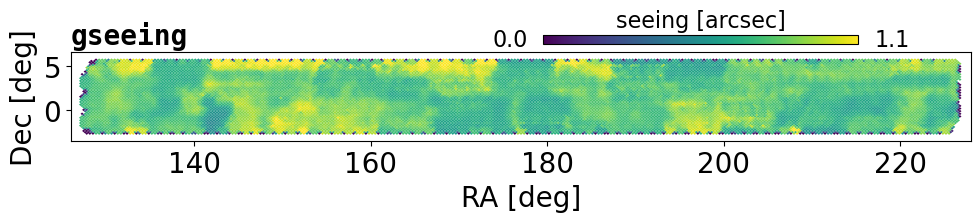

In [29]:
target = data['gseeing']
healpix = data['healpix']
ramin, ramax = (126, 228)
decmin, decmax = (-3.5, 6.5)
name = 'seeing [arcsec]'
vmin = 0.0
vmax = 1.1

fig, ax = plt.subplots(figsize=(10, 2.4))

coll = plot_map(target, healpix, vmin=vmin, vmax=vmax)
ax.add_collection(coll)

ax.set_xlim(ramin, ramax)
ax.set_ylim(decmin, decmax)

    # 左上に名前
    
    
ax.text(
    0.0, 1.03,
    "gseeing",
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=20,
    fontweight='bold',
    fontfamily='monospace'   # texttt っぽい
)

    # colorbar 用の小さい axes を自分で作る
cax = inset_axes(
    ax,
    width="35%",          # colorbar の長さ
    height="10%",          # colorbar の太さ
    loc="upper center",
    bbox_to_anchor=(0.20, 0.20, 1, 1),  # x方向に右へずらす
    bbox_transform=ax.transAxes,
    borderpad=0
)

cbar = fig.colorbar(
    coll,
    cax=cax,
    orientation='horizontal'
)

cbar.set_ticks([])

cbar.ax.text(
    -0.05, 0.5, f'{vmin}',
    transform=cbar.ax.transAxes,
    ha='right',
    va='center',
    fontsize=16
)

cbar.ax.text(
    1.05, 0.5, f'{vmax}',
    transform=cbar.ax.transAxes,
    ha='left',
    va='center',
    fontsize=16
)
    
cbar.ax.text(
    0.5, 1.3,
    'seeing [arcsec]',
    transform=cbar.ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=16
)


# Axis labels
ax.set_xlabel('RA [deg]', fontsize=20)
ax.set_ylabel('Dec [deg]', fontsize=20)
ax.set_aspect('equal')

# Ticks
xticks = np.array([140, 160, 180, 200, 220])
yticks = np.array([0, 5])

ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.tick_params(labelsize=20)

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.12,   # 下を広げる
    top=0.95
)

plt.savefig('../../figures/HeatMap/Spring/single_test.pdf',
    pad_inches=0.05)
plt.show()

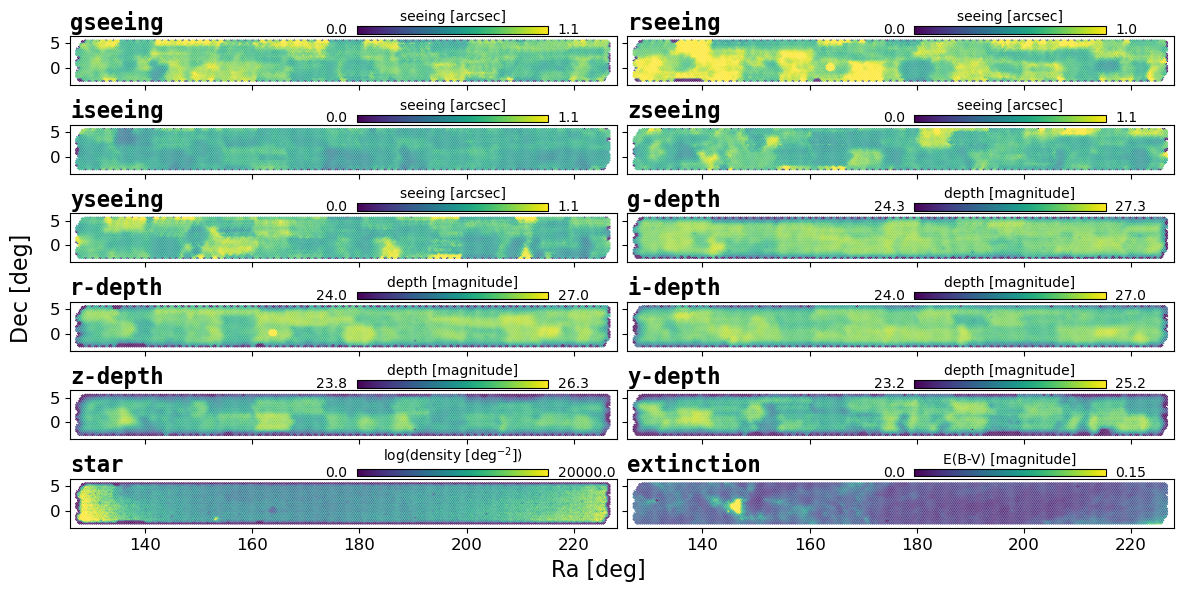

In [20]:
names = {
    'gseeing':"gseeing",
    'rseeing':"rseeing",
    'iseeing':"iseeing",
    'zseeing':"zseeing",
    'yseeing':"yseeing",
    
    'g_depth':"g-depth",
    'r_depth':"r-depth",
    'i_depth':"i-depth",
    'z_depth':"z-depth",
    'y_depth':"y-depth",
    
    'star':"star",
    'desi-csfd_extinction':"extinction"
}

unit = {
    'gseeing':'seeing [arcsec]',
    'rseeing':'seeing [arcsec]',
    'iseeing':'seeing [arcsec]',
    'zseeing':'seeing [arcsec]',
    'yseeing':'seeing [arcsec]',
    
    'g_depth':"depth [magnitude]",
    'r_depth':"depth [magnitude]",
    'i_depth':"depth [magnitude]",
    'z_depth':"depth [magnitude]",
    'y_depth':"depth [magnitude]",
    
    'star':"log(density [deg$^{-2}$])",
    'desi-csfd_extinction':"E(B-V) [magnitude]"
}

vrange = {
    'gseeing':(0.0, 1.1),
    'rseeing':(0.0, 1.0),
    'iseeing':(0.0, 1.1),
    'zseeing':(0.0, 1.1),
    'yseeing':(0.0, 1.1),
    
    'g_depth':(24.3, 27.3),
    'r_depth':(24.0, 27.0),
    'i_depth':(24.0, 27.0),
    'z_depth':(23.8, 26.3),
    'y_depth':(23.2, 25.2),
    
    'star':(0.0, 2e4),
    'desi-csfd_extinction':(0.0, 0.15)
}

keys = list(names.keys())


healpix = data['healpix']
ramin, ramax = (126, 228)
decmin, decmax = (-3.5, 6.5)

fig, axes = plt.subplots(
    6, 2,
    figsize=(12, 6),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for i, key in enumerate(keys):
    vmin, vmax = vrange[key]
    ax = axes[i]

    target = data[key]
    coll = plot_map(target, healpix, vmin=vmin, vmax=vmax)
    ax.add_collection(coll)

    ax.set_xlim(ramin, ramax)
    ax.set_ylim(decmin, decmax)

    # 左上に名前
    
    
    ax.text(
        0.0, 1.03,
        names[key],
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=16,
        fontweight='bold',
        fontfamily='monospace'   # texttt っぽい
    )

    # colorbar 用の小さい axes を自分で作る
    cax = inset_axes(
        ax,
        width="35%",          # colorbar の長さ
        height="15%",          # colorbar の太さ
        loc="upper center",
        bbox_to_anchor=(0.20, 0.20, 1, 1),  # x方向に右へずらす
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    cbar = fig.colorbar(
        coll,
        cax=cax,
        orientation='horizontal'
    )

    cbar.set_ticks([])

    cbar.ax.text(
        -0.05, 0.5, f'{vmin}',
        transform=cbar.ax.transAxes,
        ha='right',
        va='center',
        fontsize=10
    )

    cbar.ax.text(
        1.05, 0.5, f'{vmax}',
        transform=cbar.ax.transAxes,
        ha='left',
        va='center',
        fontsize=10
    )
    
    cbar.ax.text(
        0.5, 1.3,
        unit[key],
        transform=cbar.ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=10
    )


# 軸目盛り
xticks = np.array([140, 160, 180, 200, 220])
yticks = np.array([0, 5])

for ax in axes:
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.tick_params(labelsize=12)

# RA は一番下だけ
for ax in axes[:-2]:
    ax.tick_params(labelbottom=False)

# Dec は左列だけ
for ax in axes[1::2]:
    ax.tick_params(labelleft=False)

fig.supxlabel('Ra [deg]', fontsize=16, y=0.01)
fig.supylabel('Dec [deg]', fontsize=16, x=0.01)

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.10,   # 下を広げる
    top=0.92,      # 上を少し空ける
    wspace=0.02,
    hspace=0.8
)

plt.savefig(
    '../../figures/HeatMap/Spring/all_test.pdf',
    pad_inches=0.05
)

plt.show()

## density correlation fuction

In [ ]:
xrange = {
    'gseeing':(0.0, 1.1),
    'rseeing':(0.0, 1.0),
    'iseeing':(0.0, 1.1),
    'zseeing':(0.0, 1.1),
    'yseeing':(0.0, 1.1),
    
    'g_depth':(24.3, 27.3),
    'r_depth':(24.0, 27.0),
    'i_depth':(24.0, 27.0),
    'z_depth':(23.8, 26.3),
    'y_depth':(23.2, 25.2),
    
    'star':(0.0, 2e4),
    'desi-csfd_extinction':(0.0, 0.15)
}

ymin, ymax = (-0.3, 0.3)
fig, axes = plt.subplots(
    3, 4,
    figsize=(18, 12),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for i, key in enumerate(keys):
    xmin, xmax = xrange[key]
    ax = axes[i]
    
    ax.text(
        0.0, 1.03,
        names[key],
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=16,
        fontweight='bold',
        fontfamily='monospace'   # texttt っぽい
    )
    
    xbin, mean, err = stat.jackknife_dens(lin_table, key, 'target')
    ax.plot(xbin, mean, color = 'black', label = 'No Correction')
    ax.fill_between(x = xbin, y1 = mean - err, y2 = mean + err, color='black', alpha = 0.3)
    
    xbin, mean, err = stat.jackknife_dens(lin_table, key, 'weighted_target')
    ax.plot(xbin, mean, color = 'red', label = 'Linear')
    ax.fill_between(x = xbin, y1 = mean - err, y2 = mean + err, color='red', alpha = 0.3)
    
    xbin, mean, err = stat.jackknife_dens(quad_table, key, 'weighted_target')
    ax.plot(xbin, mean, color = 'green', label = 'Quadratic')
    ax.fill_between(x = xbin, y1 = mean - err, y2 = mean + err, color='green', alpha = 0.3)
    
    xbin, mean, err = stat.jackknife_dens(nn_table, key, 'weighted_target')
    ax.plot(xbin, mean, color = 'blue', label = 'Neural Network')
    ax.fill_between(x = xbin, y1 = mean - err, y2 = mean + err, color='blue', alpha = 0.3)
    
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    # 軸目盛り
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.set_xlabel(unit[key], fontsize=16, x=0.01)
    
yticks = np.array([-0.2, 0.0, 0.2])

for ax in axes:
    ax.set_yticks(yticks)
    ax.tick_params(labelsize=12)

# yaxis は左列だけ
for ax in axes[1::4]:
    ax.tick_params(labelleft=False)

fig.supylabel(r'$\frac{\bar{d}(\mathbf{s}_i)}{\bar{d}} - 1$', fontsize=16, x=0.01)

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.10,   # 下を広げる
    top=0.92,      # 上を少し空ける
    wspace=0.02,
    hspace=0.8
)

## Angular correlation function

In [ ]:
x_bin = np.linspace(0.0, 5.0, 11)
fig, axes = plt.subplots(
    3, 4,
    figsize=(18, 12),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for i, key in enumerate(keys):
    ax = axes[i]
    
    ax.text(
        0.0, 1.03,
        names[key],
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=16,
        fontweight='bold',
        fontfamily='monospace'   # texttt っぽい
    )
    
    xbin, mean, err = stat.jackknife_ang_ratio(lin_table, key, 'target', x_bin)
    ax.plot(xbin, mean, color = 'black', label = 'No Correction')
    ax.fill_between(x = xbin, y1 = mean - err, y2 = mean + err, color='black', alpha = 0.3)
    
    xbin, mean, err = stat.jackknife_ang_ratio(lin_table, key, 'weighted_target', x_bin)
    ax.plot(xbin, mean, color = 'red', label = 'Linear')
    ax.fill_between(x = xbin, y1 = mean - err, y2 = mean + err, color='red', alpha = 0.3)
    
    xbin, mean, err = stat.jackknife_ang_ratio(quad_table, key, 'weighted_target', x_bin)
    ax.plot(xbin, mean, color = 'green', label = 'Quadratic')
    ax.fill_between(x = xbin, y1 = mean - err, y2 = mean + err, color='green', alpha = 0.3)
    
    xbin, mean, err = stat.jackknife_ang_ratio(nn_table, key, 'weighted_target', x_bin)
    ax.plot(xbin, mean, color = 'blue', label = 'Neural Network')
    ax.fill_between(x = xbin, y1 = mean - err, y2 = mean + err, color='blue', alpha = 0.3)
    
    ax.set_xlim(0.0, 5.0)
    ax.set_ylim(ymin, ymax)
    
    # 軸目盛り
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.set_xlabel(unit[key], fontsize=16, x=0.01)
    
yticks = np.array([-0.2, 0.0, 0.2])

for ax in axes:
    ax.set_yticks(yticks)
    ax.tick_params(labelsize=12)

# yaxis は左列だけ
for ax in axes[1::4]:
    ax.tick_params(labelleft=False)

fig.supylabel(r'$\frac{\bar{d}(\mathbf{s}_i)}{\bar{d}} - 1$', fontsize=16, x=0.01)

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.10,   # 下を広げる
    top=0.92,      # 上を少し空ける
    wspace=0.02,
    hspace=0.8
)